# Outputs for 6th Mag LGS

## Setup Materials

In [12]:
import pylab as plt
import numpy as np
from paarti.utils import maos_utils
from paarti import psfs, psf_plots

# psf_x = [0, 5, 10, 15, 20, 25, 30, 35]  # arcsec
# psf_y = [0, 0,  0,  0,  0,  0,  0,  0,  0,  0]  # arcsec
# psf_wvl = [432, 544, 652, 810, 877, 1020, 1248, 1673, 2200]

directory = '/g/lu/data/kapa/2026mar04/maos/i260304_a021002.fits/A_keck_kapa_compare_sky_4lgs_template_seed1/'
seed = 1

%matplotlib inline

# Strehl vs. Radius

In [16]:
mets = maos_utils.get_psf_metrics_over_field(directory, seed=seed)
x, y, w, strehl, fwhm_g, fwhm_e, r_ee50, r_ee80 = mets

Looking in /g/lu/data/kapa/2026mar04/maos/i260304_a021002.fits/A_keck_kapa_compare_sky_4lgs_template_seed1/ for simulation results...
xx =  0 yy =  2
xx =  -6 yy =  0
xx =  -8 yy =  0
xx =  0 yy =  12
xx =  2 yy =  0
xx =  -10 yy =  0
xx =  0 yy =  4
xx =  0 yy =  10
xx =  0 yy =  6
xx =  6 yy =  0
xx =  0 yy =  0
xx =  4 yy =  0
xx =  12 yy =  0
xx =  8 yy =  0
xx =  10 yy =  0
xx =  -2 yy =  0
xx =  0 yy =  8
xx =  -4 yy =  0
xx =  -12 yy =  0


In [17]:
x.shape

(19, 4)

In [25]:
y.shape

(19, 4)

In [24]:
r = np.sqrt(x**2 + y**2)
r.shape

(19, 4)

In [27]:
r

array([[ 2.,  2.,  2.,  2.],
       [ 6.,  6.,  6.,  6.],
       [ 8.,  8.,  8.,  8.],
       [12., 12., 12., 12.],
       [ 2.,  2.,  2.,  2.],
       [10., 10., 10., 10.],
       [ 4.,  4.,  4.,  4.],
       [10., 10., 10., 10.],
       [ 6.,  6.,  6.,  6.],
       [ 6.,  6.,  6.,  6.],
       [ 0.,  0.,  0.,  0.],
       [ 4.,  4.,  4.,  4.],
       [12., 12., 12., 12.],
       [ 8.,  8.,  8.,  8.],
       [10., 10., 10., 10.],
       [ 2.,  2.,  2.,  2.],
       [ 8.,  8.,  8.,  8.],
       [ 4.,  4.,  4.,  4.],
       [12., 12., 12., 12.]])

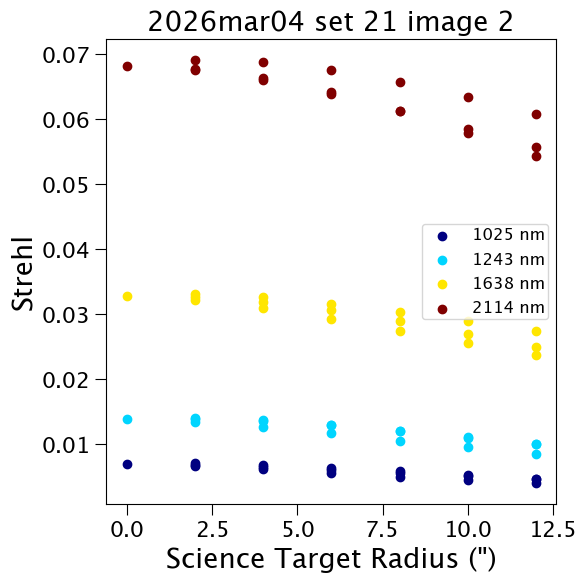

In [32]:
n_wvl = r.shape[1]
colors = plt.cm.jet(np.linspace(0,1,n_wvl))

plt.figure(1)

for ww in range(n_wvl):
    label = f'{w[0, ww]*1e3:3.0f} nm'
    plt.scatter(r[:, ww], strehl[:, ww], color=colors[ww], label=label)    

plt.xlabel('Science Target Radius (")')
plt.ylabel('Strehl')
# plt.axvline(10, linestyle='--', color='grey', label="KLGS constellation radius")
# plt.text(31, 0.2, 'LGS radius', color='grey')
plt.title('2026mar04 set 21 image 2')
plt.legend(fontsize=12)
plt.show()

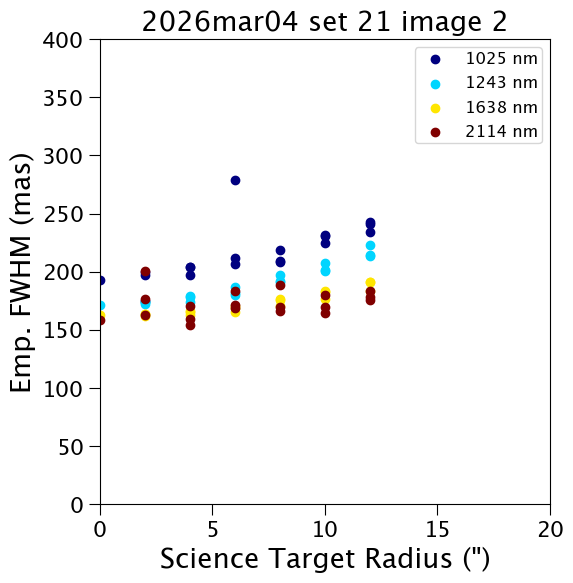

In [37]:
n_wvl = r.shape[1]
colors = plt.cm.jet(np.linspace(0,1,n_wvl))

plt.figure(1)

for ww in range(n_wvl):
    label = f'{w[0, ww]*1e3:3.0f} nm'
    plt.scatter(r[:, ww], fwhm_e[:, ww], color=colors[ww], label=label)    

plt.legend(fontsize=12)
plt.xlabel('Science Target Radius (")')
plt.ylabel('Emp. FWHM (mas)')
# plt.axvline(30, linestyle='--', color='grey')
plt.xlim(0, 20)
plt.ylim(0, 400)
# plt.text(31, 0.2, 'LGS radius', color='grey')
plt.title('2026mar04 set 21 image 2')

plt.show()

In [41]:
r_ee80.shape

(19, 4)

(0.0, 400.0)

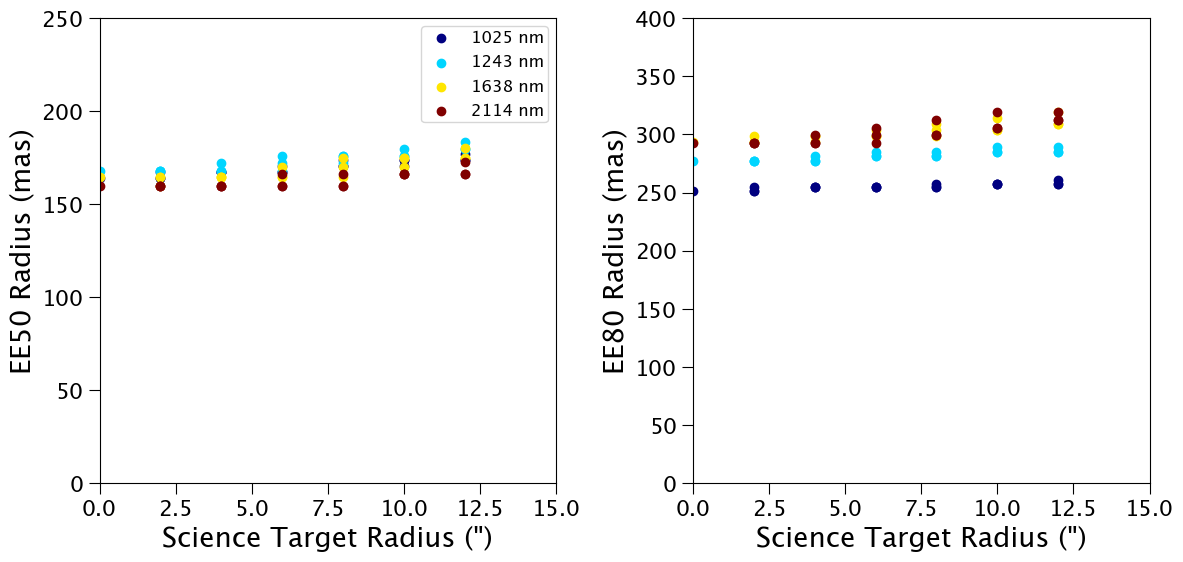

In [43]:
n_wvl = r.shape[1]
colors = plt.cm.jet(np.linspace(0,1,n_wvl))

fig, axs = plt.subplots(1, 2, figsize=(14, 6))
fig.subplots_adjust(wspace=0.3)
    
for ww in range(n_wvl):
    label = f'{w[0, ww]*1e3:3.0f} nm'
    axs[0].scatter(r[:, ww], r_ee50[:, ww], color=colors[ww], label=label)    
    axs[1].scatter(r[:, ww], r_ee80[:, ww], color=colors[ww])    

axs[0].legend(fontsize=12)
axs[0].set_xlabel('Science Target Radius (")')
axs[1].set_xlabel('Science Target Radius (")')
axs[0].set_ylabel('EE50 Radius (mas)')
axs[1].set_ylabel('EE80 Radius (mas)')
# axs[0].axvline(30, linestyle='--', color='grey')
# axs[1].axvline(30, linestyle='--', color='grey')
axs[0].set_xlim(0, 15)
axs[0].set_ylim(0, 250)
axs[1].set_xlim(0, 15)
axs[1].set_ylim(0, 400)
# axs[1].text(29, 20, 'LGS radius', color='grey', ha='right')

## Display PSFs.

800 nm PSFs vs. distance. 

In [44]:
# Pulled straight from maos_done.conf
nwfs = maos_utils.get_parameter_from_done_conf(directory, "powfs.nwfs")
wfs_x = maos_utils.get_parameter_from_done_conf(directory, "wfs.thetax")
wfs_y = maos_utils.get_parameter_from_done_conf(directory, "wfs.thetay")
wvl = maos_utils.get_parameter_from_done_conf(directory, "evl.wvl")

print(nwfs)
lgs_wfs_x = wfs_x[0:nwfs[0]]
lgs_wfs_y = wfs_y[0:nwfs[0]]

ngs_wfs_x = wfs_x[nwfs[0]:nwfs[0]+nwfs[1]]
ngs_wfs_y = wfs_y[nwfs[0]:nwfs[0]+nwfs[1]]

LGSpos = np.vstack([lgs_wfs_x, lgs_wfs_y]).T
NGSpos = np.vstack([ngs_wfs_x, ngs_wfs_y]).T

# Display 650 nm PSFs
psf_stack = psfs.MAOS_PSF_stack(directory=directory, seed=seed, bandpass=2,
                               LGSpos=LGSpos, NGSpos=NGSpos, isgrid=False)
psf_stack.calc_metrics(parallel=True, cut_radius=30)

[4 1 1]
calc_stats in parallel with 6 cores.


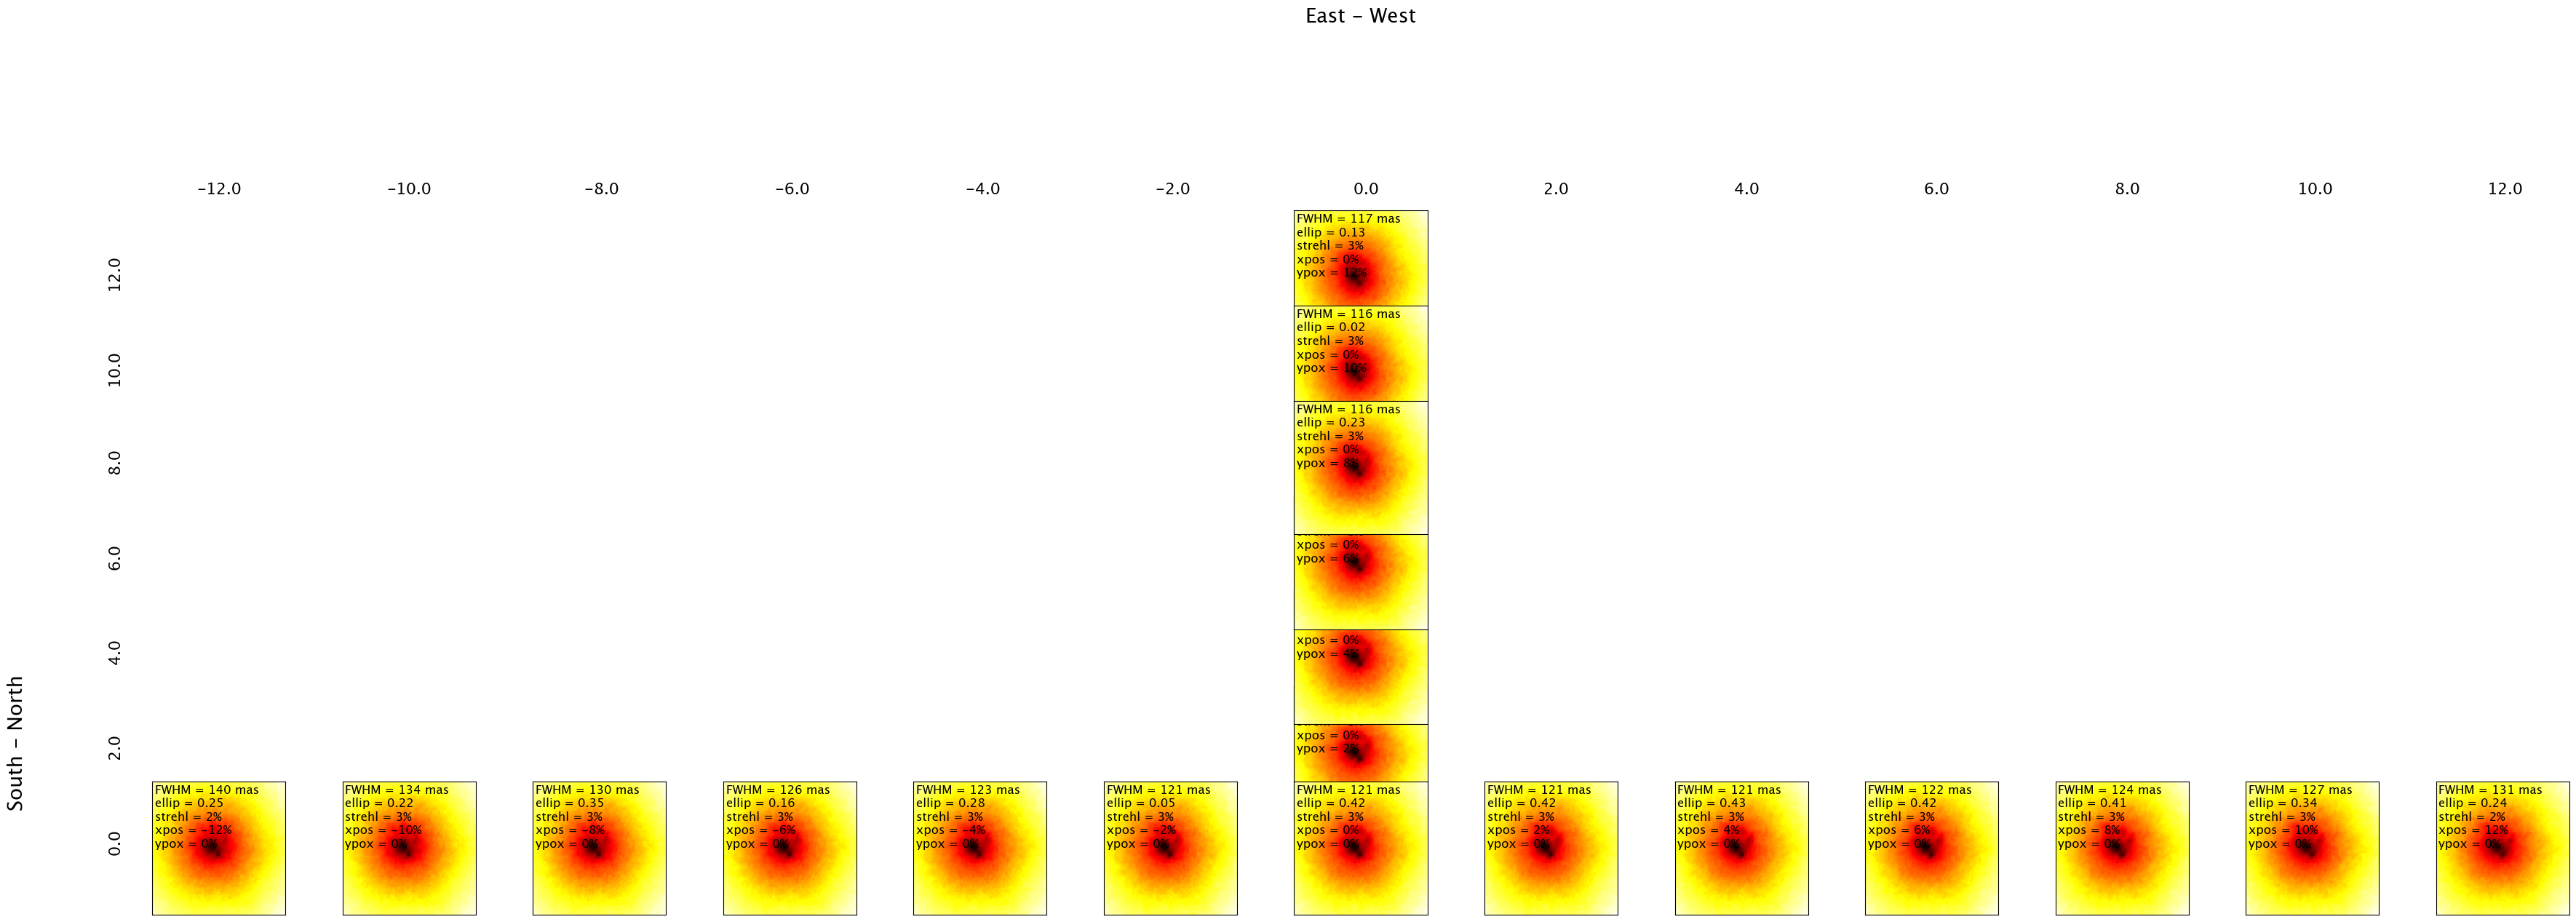

In [52]:
import copy
psf_stack_35 = copy.deepcopy(psf_stack)

idx = np.where(psf_stack_35.pos[:, 0] <= 35)[0]
psf_stack_35.psfs = psf_stack_35.psfs[idx]
psf_stack_35.pos = psf_stack_35.pos[idx]


psf_plots.plot_psf_stack(psf_stack_35, zoom=None, box_scale=1.4, figsize_max=40)

In [46]:
psf_stack_all_wvl = psfs.MAOS_PSF_all_bands_stack(directory=directory, seed=seed, 
                                                  LGSpos=LGSpos, NGSpos=NGSpos, isgrid=False)
psf_stack_all_wvl.calc_metrics(parallel=True)

calc_stats in parallel with 6 cores.


In [47]:
psf_plots.plot_psf_stack_xpos_all_wave(psf_stack_all_wvl, 5., zoom=0.2, figsize_max=20, box_scale=1.8)

ValueError: zero-size array to reduction operation minimum which has no identity

In [48]:
psf_stack_all_wvl.metrics


xpos,ypos,EE25,EE50,EE80,NEA,NEA2,emp_fwhm,fwhm,xfwhm,yfwhm,theta,ellipticity,strehl
float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64
0.0,2.0,0.088926464,0.127590144,0.177369632,0.13632800850046095,0.10196490723084208,0.134446223561951,0.19494101026283311,0.1580372359296905,0.23184478459597574,236.0110281087238,0.31834897125206396,0.00706593561890949
0.0,2.0,0.09317082,0.13594736000000002,0.19923320000000003,0.16202917831149977,0.10856794287263169,0.12226263578482846,0.16527905566472875,0.12761898346131675,0.20293912786814078,231.73465278698694,0.37114648711688114,0.014034643940536143
0.0,2.0,0.09577698000000001,0.14057589,0.22476694500000002,0.18547931819445934,0.10978718353778373,0.11857945596299738,0.16668460562082762,0.18797100253810242,0.1453982087035528,308.7490236112264,0.22648596464191306,0.03308419799645462
0.0,2.0,0.09570287999999999,0.140563605,0.23427267499999999,0.19124932679221787,0.10578424778605046,0.10825830470161153,0.15338753759708898,0.1933836052417383,0.11339146995243965,134.9306882198976,0.41364486503033615,0.06908264608824666
-6.0,0.0,0.090376352,0.130973216,0.179302816,0.14132322721556984,0.11238234989454794,0.15974307019489187,0.18025639129382978,0.21541437514347606,0.14509840744418354,321.6698273585938,0.3264218910760194,0.005620141388205468
-6.0,0.0,0.09492876000000001,0.14004922,0.20274908000000003,0.17002092800351967,0.12149011227627118,0.13834416643837952,0.16449325468325754,0.15543490033305957,0.17355160903345548,60.0486893674898,0.1043880192254718,0.011676480392657526
-6.0,0.0,0.09809416500000001,0.14598265500000002,0.23171850000000002,0.19849739288689655,0.12330747970230393,0.12614376688939183,0.1659290177566338,0.12395386333003432,0.20790417218323323,46.89267222696313,0.40379328597220543,0.029287217180726743
-6.0,0.0,0.09769669,0.146545035,0.244241725,0.20538528872638728,0.11695767460352356,0.11301054521407752,0.16129623888698066,0.21055742913161798,0.11203504864234333,310.6083758840564,0.46791215534688635,0.0638945387843606
-8.0,0.0,0.090859648,0.131939808,0.180752704,0.14369517198967707,0.11727512273593488,0.17605568159337062,0.196347251736402,0.17437969196798686,0.21831481150481713,245.9107179112288,0.20124662744589294,0.004980726006777932
